# Regression with neural networks

Any neural architecture can be used for regression

* For Multi-Layer Perceptron, just use one neuronin the output layer, with linear activation function
* Use a loss functionthat evaluates regression tasks, such as Mean Squared (or Absolute) Error
* Specific architectures are dedicated to time-series analysis: i.e., recurrent neural networkssuch as Long Short-Term Memory (LSTM) networks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../dataset/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
df.shape

(506, 14)

In [4]:
X = df.drop('medv',axis='columns')
y = df['medv']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input

input_shape = (X_train.shape[1],)
model = Sequential([
Input(shape=input_shape),

Dense(100, activation="sigmoid"),

Dense(100, activation="sigmoid"),

Dense(1, activation="linear")
])

## What happens if I use activation = 'sigmoid' in the last layer?

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,601 (45.32 KB)

 Trainable params: 11,601 (45.32 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from keras.callbacks import EarlyStopping
model.compile(loss='mse', optimizer='adam')
es = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[es])

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 575.4246 - val_loss: 568.8744
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 558.4089 - val_loss: 559.5458
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 553.3301 - val_loss: 557.7040
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 552.2925 - val_loss: 557.2598
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 551.9987 - val_loss: 557.1026
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 551.8857 - val_loss: 557.0284
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 551.8282 - val_loss: 556.9844
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 551.7914 - val_loss: 556.9541
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 551.7653 - val_loss: 556.9305
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 551.7443 - val_loss: 556.9112
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 551.7267 - val_loss: 556.8954
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s

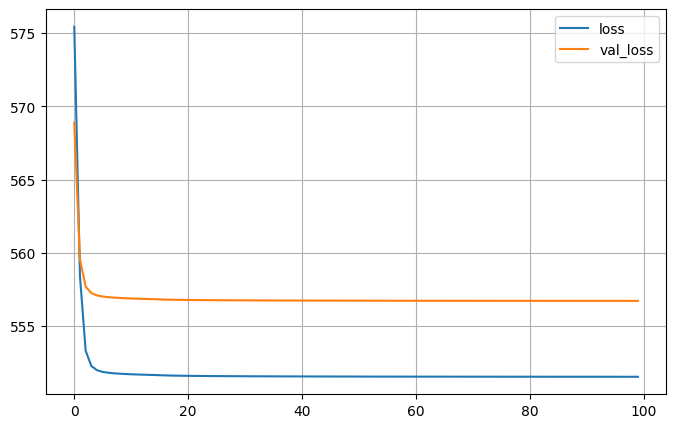

In [12]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca()
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
y_pred = model.predict(X_test)
print('MAE =', mean_absolute_error(y_test, y_pred))
print('MAPE =',mean_absolute_percentage_error(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
MAE = 21.33381849574415
MAPE = 0.9458869527729231


In [14]:
y_pred

array([[0.9997725 ],
       [0.9997734 ],
       [0.9997643 ],
       [0.9997734 ],
       [0.9997727 ],
       [0.9997726 ],
       [0.99970543],
       [0.9997742 ],
       [0.9997735 ],
       [0.9997725 ],
       [0.9997725 ],
       [0.999705  ],
       [0.999705  ],
       [0.9997669 ],
       [0.9997733 ],
       [0.9997725 ],
       [0.9997715 ],
       [0.9995235 ],
       [0.99977255],
       [0.999705  ],
       [0.9997713 ],
       [0.9997049 ],
       [0.9996313 ],
       [0.99977124],
       [0.99958074],
       [0.99977475],
       [0.9997725 ],
       [0.9997736 ],
       [0.99970496],
       [0.99976385],
       [0.9997623 ],
       [0.9997725 ],
       [0.99952704],
       [0.99954045],
       [0.99977326],
       [0.99970526],
       [0.999705  ],
       [0.99977297],
       [0.99977165],
       [0.99976826],
       [0.99970496],
       [0.9997725 ],
       [0.9997629 ],
       [0.9995163 ],
       [0.9997727 ],
       [0.99975914],
       [0.99977106],
       [0.999